### Phase 1: Structural Demand and Elasticity Validation

Following the initial data collection phase, the Pricing Manager brings in a Data Scientist to support the development of more rigorous analytical and modeling capabilities. The objective is to transition from exploratory pricing to a structured understanding of demand dynamics.

In this phase, the Data Scientist conducts a comprehensive econometric evaluation of the dataset. This includes analyzing correlations, visualizing key relationships through graphs, and estimating structural models to uncover the underlying economic mechanisms driving demand.

The focus is on validating whether the simulated environment produces economically consistent and statistically identifiable demand behavior. Building on the exploratory analysis, the goal is to ensure that the demand function can be reliably learned from data, particularly with respect to price elasticity and key market drivers.

This phase therefore emphasizes isolating the core economic relationships embedded in the simulation. Specifically, we aim to verify that:
- Demand responds negatively and nonlinearly to price;  
- Price elasticity behaves consistently across different demand regimes;  
- Seasonal effects shift demand levels in a stable and learnable manner;  
- The system remains identifiable when excluding redundant or state-driven features.  

In [1]:
import pickle
import random
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
rng = np.random.default_rng()

In [2]:
df = pd.read_csv("data/phase_0.csv", parse_dates=["date"])

df["rel_price"] = np.clip(np.log(df["price_competitor"]) - np.log(df["price_agent"]), -0.8, 0.8)
df["competitor_lag_1"] = df["price_competitor"].shift(1)
df["rel_price_lag_1"] = df["rel_price"].shift(1)
df["price_lag_1"] = df["price_agent"].shift(1)
df["lag_1"] = df["realized_demand"].shift(1)

df = df[df["realized_demand"] > 0].copy()
df = df.dropna().reset_index(drop=True)

print(df.shape)
df.tail()

(89, 12)


,date,price_agent,price_competitor,season_signal,demand_shock,realized_demand,revenue,rel_price,competitor_lag_1,rel_price_lag_1,price_lag_1,lag_1
84,2025-03-27,100.000000,133.046471,2.100213e-05,-0.051623,16.235496,449.419827,0.285528,153.048743,-0.044417,160.000000,4.091612
85,2025-03-28,104.916917,144.938703,7.726252e-06,-0.049898,16.719392,550.983552,0.323142,133.046471,0.285528,100.000000,16.235496
86,2025-03-29,160.000000,160.000000,2.718770e-06,-0.177625,3.754896,175.489575,0.000000,144.938703,0.323142,104.916917,16.719392
87,2025-03-30,130.501164,160.000000,9.151115e-07,-0.071697,9.134093,443.964167,0.203792,160.000000,0.000000,160.000000,3.754896
88,2025-03-31,144.589350,127.327932,2.946277e-07,0.064606,4.089074,145.892151,-0.127132,160.000000,0.203792,130.501164,9.134093


In [3]:
df[["realized_demand", "price_agent", "price_competitor", "rel_price",
    "season_signal", "lag_1", "price_lag_1", "competitor_lag_1",
    "rel_price_lag_1"]].corr()

,realized_demand,price_agent,price_competitor,rel_price,season_signal,lag_1,price_lag_1,competitor_lag_1,rel_price_lag_1
realized_demand,1.000000,-0.631295,0.504825,0.782001,0.486132,0.148720,0.230098,0.301479,0.039011
price_agent,-0.631295,1.000000,-0.069468,-0.752653,0.086434,0.076166,-0.162265,-0.089359,0.055419
price_competitor,0.504825,-0.069468,1.000000,0.706646,0.242447,0.101176,0.096354,0.380751,0.180847
rel_price,0.782001,-0.752653,0.706646,1.000000,0.099633,0.016401,0.173662,0.316232,0.084314
season_signal,0.486132,0.086434,0.242447,0.099633,1.000000,0.465806,0.098166,0.261808,0.103399
lag_1,0.148720,0.076166,0.101176,0.016401,0.465806,1.000000,-0.625782,0.491147,0.769379
price_lag_1,0.230098,-0.162265,0.096354,0.173662,0.098166,-0.625782,1.000000,-0.067583,-0.751244
competitor_lag_1,0.301479,-0.089359,0.380751,0.316232,0.261808,0.491147,-0.067583,1.000000,0.706822
rel_price_lag_1,0.039011,0.055419,0.180847,0.084314,0.103399,0.769379,-0.751244,0.706822,1.000000


The correlation structure indicates a **well-identified demand system with strong economic consistency**. Demand shows a clear negative relationship with the agent’s price (-0.63), confirming the expected downward-sloping demand curve. At the same time, demand is positively correlated with competitor price (0.50) and even more strongly with relative price (0.78), suggesting that **competitive positioning is a primary driver of demand**. This indicates that customers respond not only to absolute prices but also to how the agent is priced relative to the market.

There is **limited collinearity between agent and competitor prices** (-0.07), which is a very desirable property. This means the model can separately identify own-price and cross-price elasticities without instability. The strong correlation between relative price and both price components is expected by construction, but it reinforces that **relative pricing is a sufficient statistic for competitive effects**, potentially simplifying modeling choices.

Seasonality plays a **meaningful but secondary role**. Its correlation with demand (0.49) confirms that cyclical effects are present and economically relevant, but it does not dominate price effects. The correlation with lagged demand (0.47) also suggests some persistence in demand conditions, indicating that **state dependence exists but is not overwhelming**, leaving room for price-driven variation to be identified.

Lagged variables show moderate relationships with current demand and prices, but none are excessively strong, which suggests **limited autocorrelation and good temporal mixing** in the data. This is important because it reduces the risk of spurious dynamics and reinforces that the dataset is suitable for both econometric modeling and policy learning. Overall, the system appears **stationary, identifiable, and economically coherent**, providing a solid foundation for elasticity estimation and subsequent optimization.

In [4]:
df["log_price"] = np.log(df["price_agent"] / df["price_agent"].mean())
df["log_comp"] = np.log(df["price_competitor"] / df["price_competitor"].mean())

print("Log price var:", df["log_price"].var().round(4))
print("Comp price var:", df["log_comp"].var().round(4))

Log price var: 0.033
Comp price var: 0.0297


In [5]:
print('Std:', df["price_agent"].std().round(4))
print('Mean:', df["price_agent"].mean().round(4))
print("Coef. var:", (df["price_agent"].std() / df["price_agent"].mean()).round(4))

Std: 23.3262
Mean: 133.3599
Coef. var: 0.1749


In [6]:
print('Std:', df["price_competitor"].std().round(4))
print('Mean:', df["price_competitor"].mean().round(4))
print("Coef. var:", (df["price_competitor"].std() / df["price_competitor"].mean()).round(4))

Std: 22.2004
Mean: 131.5888
Coef. var: 0.1687


The observed level of price variation is sufficient to ensure **identifiability of both own- and cross-price elasticities**. With coefficients of variation around 17% for both agent and competitor prices and log-price variances near 0.03, the data exhibits meaningful dispersion in relative price space without being excessively noisy. This implies that prices move enough, and importantly, move independently enough, to generate variation in demand responses that can be attributed to each price component. As a result, the regression is able to disentangle the effects of own price from competitor price, avoiding the typical collinearity issues seen in tightly coupled pricing systems.

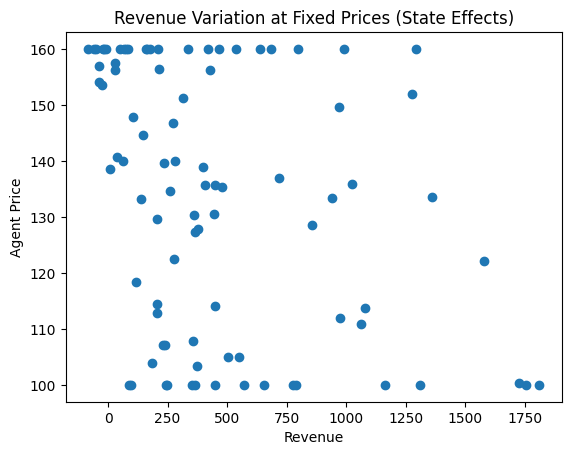

In [15]:
plt.scatter(df["revenue"], df["price_agent"])
plt.xlabel("Revenue")
plt.ylabel("Agent Price")
plt.title("Revenue Variation at Fixed Prices (State Effects)")
plt.show()

In [8]:
df["state_bin"] = pd.qcut(df["season_signal"], 4)
df.groupby("state_bin")["price_agent"].describe()

C:\Users\Breno\AppData\Local\Temp\ipykernel_14692\3319917165.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("state_bin")["price_agent"].describe()


,count,mean,std,min,25%,50%,75%,max
state_bin,,,,,,,,
"(-0.000999705, 0.000352]",23.0,133.002822,21.160519,100.0,116.653376,133.242169,151.621533,160.0
"(0.000352, 0.044]",22.0,125.853275,24.810888,100.0,103.482605,114.244541,153.993062,160.0
"(0.044, 0.69]",22.0,136.242811,23.362977,100.0,114.912412,139.800015,160.000000,160.0
"(0.69, 1.079]",22.0,138.356734,23.570118,100.0,124.879629,144.263888,160.000000,160.0


Revenue appears only weakly state-dependent through pricing. While average prices increase slightly across state bins, the differences are small relative to the high within-bin variance, indicating that pricing is not strongly driven by state. At the same time, the price–revenue scatter shows large dispersion for similar price levels, suggesting that revenue variation is primarily driven by demand conditions rather than price alone. Overall, state impacts revenue mainly through demand, with pricing playing a secondary and only partially adaptive role.

C:\Users\Breno\AppData\Local\Temp\ipykernel_14692\3636696654.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rev_effect = df.groupby(bins)["revenue"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_14692\3636696654.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_effect = df.groupby(bins)["price_agent"].mean()
C:\Users\Breno\AppData\Local\Temp\ipykernel_14692\3636696654.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(price_effect.values.astype(np.int16))


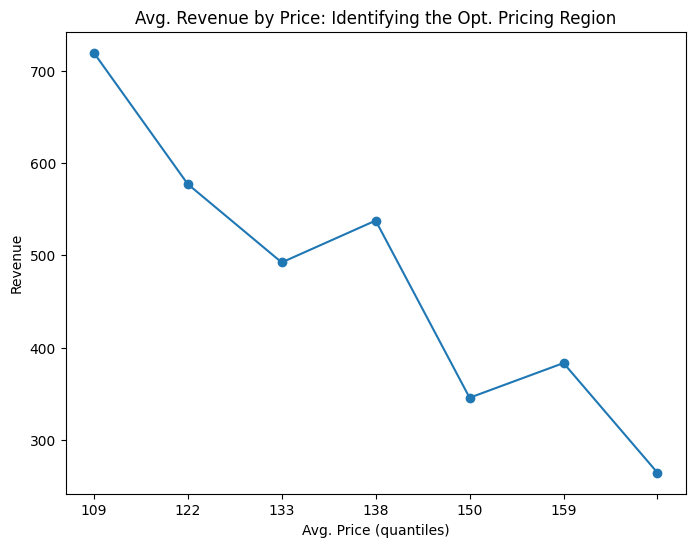

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

bins = pd.qcut(df["price_agent"], 10, duplicates="drop")
rev_effect = df.groupby(bins)["revenue"].mean()
price_effect = df.groupby(bins)["price_agent"].mean()

ax.set_xticklabels(price_effect.values.astype(np.int16))

plt.plot(rev_effect.values, marker="o")
plt.title("Revenue vs Price")
plt.xlabel("Avg. Price (quantiles)")
plt.ylabel("Revenue")

plt.title("Avg. Revenue by Price: Identifying the Opt. Pricing Region")
plt.show()

The graph shows a clear negative relationship between price and average revenue, indicating that higher prices tend to reduce overall performance in this setting. Revenue is maximized at the lower end of the price range, with a noticeable decline as prices increase, despite a small local rebound around the mid-range. This suggests that demand is sufficiently price-sensitive such that increases in price are not compensated by higher margins. The optimal pricing region appears to lie toward the lower quantiles, where the balance between price and demand generates higher revenue.

#### Structural models

A two-stage modeling approach is used to separate the direct effects of pricing from latent demand conditions that are not explicitly observed. In the first stage, log demand is regressed only on own price and competitor price. While this specification captures the main economic relationships, the residuals contain systematic variation driven by omitted factors such as seasonality and demand shocks. These residuals are therefore interpreted as a proxy for latent demand. In the second stage, this latent demand proxy is included as an additional regressor alongside price variables.

In [ ]:
df["log_demand"] = np.log(df["realized_demand"])
df["price_squared"] = - df["log_price"] ** 2

X = df[["log_price", "log_comp"]]
X = sm.add_constant(X) 

y = df["log_demand"]

model_struct = sm.OLS(y, X).fit()
model_struct.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_demand   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     199.7
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           4.82e-33
Time:                        08:41:17   Log-Likelihood:                -38.122
No. Observations:                  89   AIC:                             82.24
Df Residuals:                      86   BIC:                             89.71
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0165      0.040     49.960      0.000       1.936       2.097
log_price     -3.2934      0.222    -14.830      0.000      -3.735      -2.852
log_comp       2.8911      0.234     12.346      0.000       2.426       3.357
==============================================================================
Omnibus:                        7.511   Durbin-Watson:                   0.404
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                7.247
Skew:                           0.641   Prob(JB):                       0.0267
Kurtosis:                       2.442   Cond. No.                         5.94
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
df["residuals"] = df["log_demand"] - model_struct.predict(X)
df[["residuals", "log_price", "log_comp"]].corr()

,residuals,log_price,log_comp
residuals,1.000000e+00,8.026559e-16,-5.995700e-16
log_price,8.026559e-16,1.000000e+00,-6.856056e-02
log_comp,-5.995700e-16,-6.856056e-02,1.000000e+00


In [12]:
df["state_proxy"] = df["residuals"].ewm(alpha=.3).mean()

X = df[["log_price", "log_comp", "state_proxy"]]
X = sm.add_constant(X) 

y = df["log_demand"]

model_struct = sm.OLS(y, X).fit()
model_struct.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_demand   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     602.7
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           3.81e-57
Time:                        08:41:18   Log-Likelihood:                 22.969
No. Observations:                  89   AIC:                            -37.94
Df Residuals:                      85   BIC:                            -27.98
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.9864      0.021     96.778      0.000       1.946       2.027
log_price      -3.4136      0.113    -30.289      0.000      -3.638      -3.190
log_comp        2.7440      0.119     23.072      0.000       2.508       2.981
state_proxy     1.0770      0.068     15.826      0.000       0.942       1.212
==============================================================================
Omnibus:                       33.006   Durbin-Watson:                   0.805
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               57.775
Skew:                           1.521   Prob(JB):                     2.85e-13
Kurtosis:                       5.516   Cond. No.                         5.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [13]:
df["residuals_2"] = df["log_demand"] - model_struct.predict(X)
df[["residuals_2", "log_price", "log_comp", "state_proxy"]].corr()

,residuals_2,log_price,log_comp,state_proxy
residuals_2,1.000000e+00,2.388333e-16,-8.820607e-18,8.385453e-16
log_price,2.388333e-16,1.000000e+00,-6.856056e-02,6.201624e-02
log_comp,-8.820607e-18,-6.856056e-02,1.000000e+00,7.353440e-02
state_proxy,8.385453e-16,6.201624e-02,7.353440e-02,1.000000e+00


From steps 1 to 2 the model fit improves substantially (R² increases from 0.82 to 0.96), and the coefficients remain economically consistent. The latent demand term is highly significant, indicating that a large share of demand variation is driven by factors not captured by prices alone.

This approach highlights that ignoring latent demand can lead to incomplete elasticity estimation. By explicitly incorporating a proxy for these hidden drivers, the second-stage model provides a more accurate and structurally meaningful representation of demand dynamics.

In [14]:
df.to_csv("data/phase_1.csv", index=False)